In [1]:
import pandas as pd
import numpy as np
import joblib
import mlflow
import mlflow.xgboost
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (classification_report, 
                             confusion_matrix,
                             roc_auc_score,
                             average_precision_score)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported")

Libraries imported


In [2]:
X_train = joblib.load('../models/X_train.pkl')
X_test  = joblib.load('../models/X_test.pkl')
y_train = joblib.load('../models/y_train.pkl')
y_test  = joblib.load('../models/y_test.pkl')

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Fraud in train: {y_train.sum()}")
print(f"Fraud in test:  {y_test.sum()}")

X_train: (5090096, 11)
X_test:  (1272524, 11)
Fraud in train: 6570
Fraud in test:  1643


In [3]:
# SMOTE only on training data — NEVER on test data
print("Applying SMOTE...")
print(f"Before SMOTE - Fraud: {y_train.sum()}, Genuine: {(y_train==0).sum()}")

smote = SMOTE(random_state=42, sampling_strategy=0.1)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"After SMOTE  - Fraud: {y_train_sm.sum()}, Genuine: {(y_train_sm==0).sum()}")
print(f"New training shape: {X_train_sm.shape}")

Applying SMOTE...
Before SMOTE - Fraud: 6570, Genuine: 5083526
After SMOTE  - Fraud: 508352, Genuine: 5083526
New training shape: (5591878, 11)


In [4]:
def evaluate_model(model_name, y_test, y_pred, y_prob):
    print(f"\n{'='*50}")
    print(f"MODEL: {model_name}")
    print(f"{'='*50}")
    print(f"ROC-AUC Score:        {roc_auc_score(y_test, y_prob):.4f}")
    print(f"Avg Precision Score:  {average_precision_score(y_test, y_prob):.4f}")
    print()
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    print()
    print(f"Fraud cases in test:      {y_test.sum()}")
    print(f"Fraud correctly detected: {cm[1][1]}")
    print(f"Fraud missed:             {cm[1][0]}")
    print(f"False alarms:             {cm[0][1]}")
    print()
    print(classification_report(y_test, y_pred))
    print(f"{'='*50}")

In [5]:
print("Training XGBoost...")

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=10,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_sm, y_train_sm)
print("XGBoost training done")

Training XGBoost...
XGBoost training done


In [6]:
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb > 0.3).astype(int)

evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb)


MODEL: XGBoost
ROC-AUC Score:        0.9995
Avg Precision Score:  0.9984

Confusion Matrix:
[[1270781     100]
 [      4    1639]]

Fraud cases in test:      1643
Fraud correctly detected: 1639
Fraud missed:             4
False alarms:             100

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.94      1.00      0.97      1643

    accuracy                           1.00   1272524
   macro avg       0.97      1.00      0.98   1272524
weighted avg       1.00      1.00      1.00   1272524



In [7]:
print("Training LightGBM...")

lgbm_model = LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=10,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_model.fit(X_train_sm, y_train_sm)
print("LightGBM training done")

Training LightGBM...
LightGBM training done


In [8]:
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]
y_pred_lgbm = (y_prob_lgbm > 0.3).astype(int)

evaluate_model("LightGBM", y_test, y_pred_lgbm, y_prob_lgbm)


MODEL: LightGBM
ROC-AUC Score:        0.9975
Avg Precision Score:  0.4386

Confusion Matrix:
[[1268206    2675]
 [      7    1636]]

Fraud cases in test:      1643
Fraud correctly detected: 1636
Fraud missed:             7
False alarms:             2675

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.38      1.00      0.55      1643

    accuracy                           1.00   1272524
   macro avg       0.69      1.00      0.77   1272524
weighted avg       1.00      1.00      1.00   1272524



In [9]:
print("\nMODEL COMPARISON")
print("="*50)
print(f"{'Metric':<25} {'XGBoost':>10} {'LightGBM':>10}")
print("-"*50)
print(f"{'ROC-AUC':<25} {roc_auc_score(y_test, y_prob_xgb):>10.4f} {roc_auc_score(y_test, y_prob_lgbm):>10.4f}")
print(f"{'Avg Precision':<25} {average_precision_score(y_test, y_prob_xgb):>10.4f} {average_precision_score(y_test, y_prob_lgbm):>10.4f}")

cm_xgb  = confusion_matrix(y_test, y_pred_xgb)
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

print(f"{'Fraud Detected':<25} {cm_xgb[1][1]:>10} {cm_lgbm[1][1]:>10}")
print(f"{'Fraud Missed':<25} {cm_xgb[1][0]:>10} {cm_lgbm[1][0]:>10}")
print(f"{'False Alarms':<25} {cm_xgb[0][1]:>10} {cm_lgbm[0][1]:>10}")
print("="*50)


MODEL COMPARISON
Metric                       XGBoost   LightGBM
--------------------------------------------------
ROC-AUC                       0.9995     0.9975
Avg Precision                 0.9984     0.4386
Fraud Detected                  1639       1636
Fraud Missed                       4          7
False Alarms                     100       2675


In [10]:
mlflow.set_experiment("mobile-fraud-detection")

with mlflow.start_run(run_name="XGBoost_final"):
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("threshold", 0.3)
    mlflow.log_param("smote_strategy", 0.1)
    
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_prob_xgb))
    mlflow.log_metric("avg_precision", average_precision_score(y_test, y_prob_xgb))
    mlflow.log_metric("fraud_detected", int(cm_xgb[1][1]))
    mlflow.log_metric("fraud_missed", int(cm_xgb[1][0]))
    
    mlflow.xgboost.log_model(xgb_model, "xgb_model")
    
    print("MLflow run logged successfully")

2026/04/25 18:43:56 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/25 18:43:57 INFO mlflow.store.db.utils: Updating database tables
2026/04/25 18:44:14 INFO mlflow.tracking.fluent: Experiment with name 'mobile-fraud-detection' does not exist. Creating a new experiment.
2026/04/25 18:44:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLflow run logged successfully


In [11]:
joblib.dump(xgb_model,  '../models/xgb_model.pkl')
joblib.dump(lgbm_model, '../models/lgbm_model.pkl')

print("Models saved to models/ folder")

Models saved to models/ folder


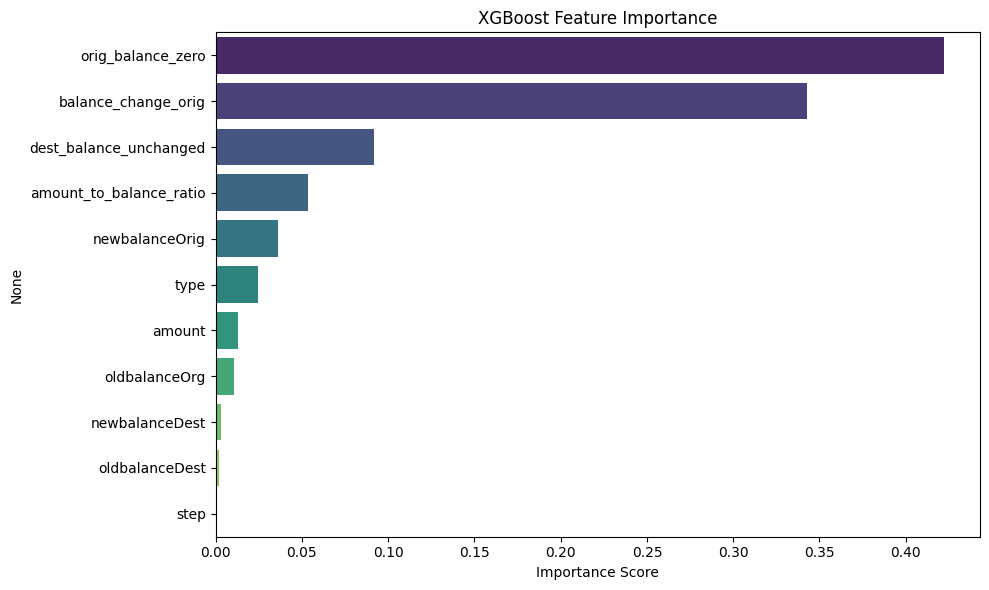

Feature importance chart saved


In [12]:
feat_imp = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../reports/feature_importance.png')
plt.show()
print("Feature importance chart saved")

In [13]:
print("=" * 50)
print("MODEL TRAINING COMPLETE")
print("=" * 50)
print(f"Best Model:           XGBoost")
print(f"ROC-AUC:              {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"Avg Precision:        {average_precision_score(y_test, y_prob_xgb):.4f}")
print(f"Fraud Detected:       {cm_xgb[1][1]} / {y_test.sum()}")
print(f"Detection Rate:       {cm_xgb[1][1]/y_test.sum()*100:.1f}%")
print("=" * 50)
print("Ready for Notebook 04 - SHAP Analysis")

MODEL TRAINING COMPLETE
Best Model:           XGBoost
ROC-AUC:              0.9995
Avg Precision:        0.9984
Fraud Detected:       1639 / 1643
Detection Rate:       99.8%
Ready for Notebook 04 - SHAP Analysis
